# Bandit Problem

In [1]:
# imports
from bandits import Bandit
import random
# Include your imports here, if any are used. 
import numpy as np
import matplotlib.pylab as plt

A list of ten bandit objects initialized in the list...

In [2]:
bandits = [Bandit(random.random()*4-2) for _ in range(10)]

In [3]:
bandits[0].pullLever()

-0.08356477808356061

## Greedy algorithm Implementation

In [4]:
def run_greedy(n):
    # TODO: Implement the greedy algorithm here
    # Return the reward from the bandits in a list
    
    tot_reward = np.array([0]*10)
    avg_reward = np.array([0]*10)
    count = np.array([0]*10)
    cumulative_reward = np.array([0]*n)

    for j in range(10):
        for i in range(10):
                rew  = bandits[i].pullLever()
                tot_reward[i]+=rew
                count[i]+=1
                avg_reward[i] = (tot_reward[i])/count[i]
                cumulative_reward[10*j+i] = rew

    for i in range(n-100):
        
        
        best = avg_reward.argmax()

        newr = bandits[best].pullLever()
        
        avg_reward[best] = (avg_reward[best]*count[best] + newr)/(count[best]+1)
        tot_reward[best]+=newr
        count[best]+=1

        
        cumulative_reward[i+100] =  newr

    return np.cumsum(cumulative_reward)/np.arange(1,(n+1))
    pass

Plot the cumulative average of rewards as the number of iterations increases.

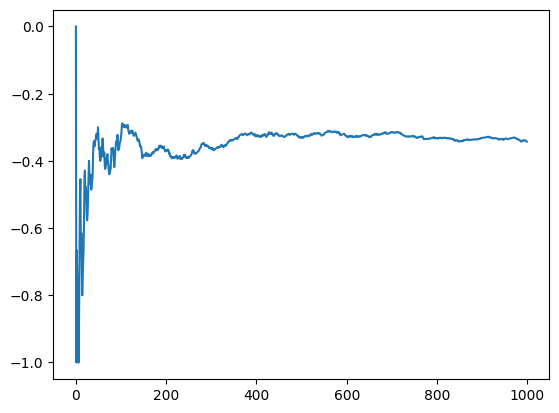

In [5]:
x = run_greedy(1000)

plt.plot(x)
plt.show()

## $\epsilon$-greedy Algorithm

In [6]:
def run_epsilon_greedy(epsilon,n):
    # TODO: Implement the epsilon greedy algorithm here
    # Return the reward from the bandits in a list
    tot_reward = np.array([0]*10)
    avg_reward = np.array([0]*10)
    count = np.array([0]*10)
    cumulative_reward = np.array([0]*n)

    for j in range(10):
        for i in range(10):
                rew  = bandits[i].pullLever()
                tot_reward[i]+=rew
                count[i]+=1
                avg_reward[i] = (tot_reward[i])/count[i]
                cumulative_reward[10*j+i] = rew
    

    for i in range(n-100):
        if random.random() < epsilon:
            best = random.randint(0,9)
        
        else :
            best = avg_reward.argmax()

        newr = bandits[best].pullLever()
        
        tot_reward[best]+=newr
        count[best]+=1
        avg_reward[best] = (tot_reward[best])/count[best]
        

        cumulative_reward[i+100] =  newr

    return np.cumsum(cumulative_reward)/np.arange(1,(n+1))
    pass

Plot the cumulative average of rewards as the number of iterations increases but for various values of $\epsilon$.

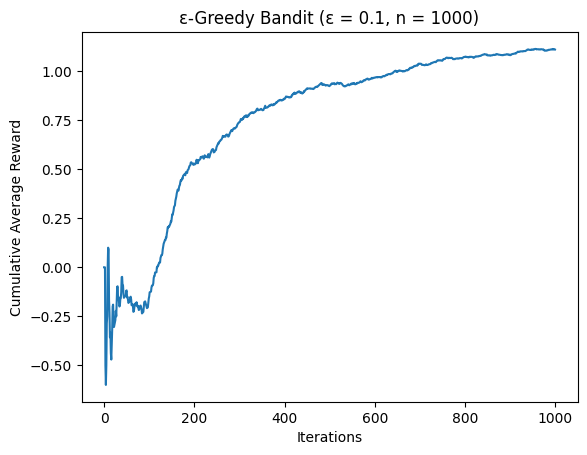

In [7]:
epsilon = 0.1
n = 1000
avg_rewards = run_epsilon_greedy(epsilon, n)

# Plot cumulative average reward
plt.figure()
plt.plot(avg_rewards)
plt.xlabel("Iterations")
plt.ylabel("Cumulative Average Reward")
plt.title("ε-Greedy Bandit (ε = 0.1, n = 1000)")
plt.show()

## Finding the optimal $\epsilon$

Run the $\epsilon$-greedy algorithm for 1000 iterations and find the optimal $\epsilon$ value by plotting the cumulative average of rewards for various values of $\epsilon$

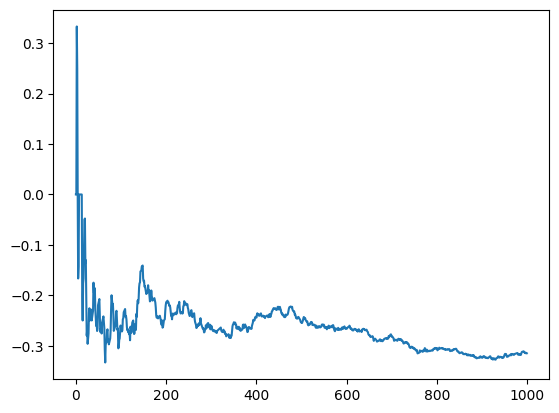

0.030303030303030304


In [17]:
z = np.linspace(0,1,100,endpoint=True)
y = -99999999
e =-1
for i in z:
    x = run_epsilon_greedy(i,1000)
    x = np.cumsum(x)
    if x[999] > y:
        y = x[999]
        e = i

p = run_epsilon_greedy(y,1000)
plt.plot(p)
plt.show()
print(e)

## Optimistic Initial Values

In [27]:
def run_optimistic_greedy(n):
    # TODO: Implement the optimistic greedy algorithm here

    # Return the reward from the bandits in a list
    
    tot_reward = np.array([0]*10)
    avg_reward = np.array([0]*10)
    count = np.array([0]*10)
    cumulative_reward = np.array([0]*n)

    for k in range(10):
        avg_reward[k] = bandits[k].get_mean() + 3*(bandits[k].get_stddev())

    for i in range(n):
        
        best = avg_reward.argmax()

        newr = bandits[best].pullLever()
        
        avg_reward[best] = (avg_reward[best]*count[best] + newr)/(count[best]+1)
        tot_reward[best]+=newr
        count[best]+=1

        cumulative_reward[i] =  newr

    return np.cumsum(cumulative_reward)/np.arange(1,(n+1))
    pass

Plot the cumulative average of rewards as the number of iterations increases for an optimistic greedy of $Q_1 = 10$ and a non-optimistic $\epsilon = 0.1$

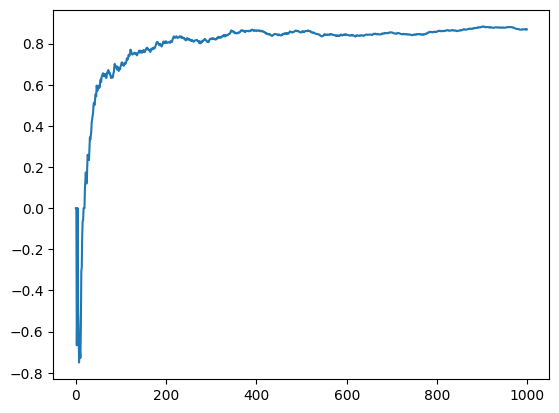

In [46]:
z = run_optimistic_greedy(1000)
plt.plot(z)
plt.show()

## Optional - Upper Confidence Bound (UCB)

In [17]:
def run_ucb(c):
    # TODO: Implement the UCB algorithm here
    # Return the reward from the bandits in a list
    pass